# IoT sensor against ERA5 reanalysis - does the deployed hardware agree with the training data?

**The mesh network now returns real readings. Are they interchangeable with the
reanalysis the models were trained on, and what happens to a forecast if they
are not?**

---

## Why this matters

Every model in this thesis was trained on **ERA5 reanalysis**. The operational
system is meant to run on **IoT sensors**. Those are two different instruments
measuring what is nominally the same quantity, and nothing so far has checked
that they agree. If they do not, every prediction the deployed system makes is
scored on inputs the model has never seen - the textbook definition of
*training/serving skew*.

`1_DATA/meteo_log.csv` is the first real capture from the deployed node
(Meshtastic `!a0cb4a5c`). It carries temperature, relative humidity and
barometric pressure. **It carries no precipitation**, which the model does use.

Three questions, in order:

1. **Do the two sources agree?** Hour-matched, over the overlapping window.
2. **If not, why?** Is the sensor faulty, or is it measuring something else?
3. **What does the disagreement cost?** In predicted cases, through the deployed
   model.

## What the data allows, and what it does not

The capture spans **seven days**, of which only **one** is complete. That is far
too short to validate a monthly model. So this is deliberately *not* a
performance study: it is an **instrument-agreement study**, which seven days can
support, followed by a **sensitivity analysis** of the forecast to whatever
disagreement is found.

---
## 0 . Setup

In [1]:
import json, sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 150, 'font.size': 10,
                     'axes.titlesize': 12, 'axes.labelsize': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})

BLUE, ORANGE, GREEN, RED = '#378ADD', '#D85A30', '#639922', '#E24B4A'
GREY, PURPLE = '#7f8c8d', '#8e44ad'

HERE = Path.cwd()
ROOT = HERE.parent if (HERE.parent / '1_DATA').is_dir() else HERE
DATA, APP = ROOT / '1_DATA', ROOT / '6_APP'
OUT_DIR = HERE / 'figures'; OUT_DIR.mkdir(exist_ok=True)
if str(APP) not in sys.path:
    sys.path.insert(0, str(APP))

# Cameroon is UTC+1. The log is stamped UTC, so every local statistic shifts.
TZ_OFFSET = pd.Timedelta(hours=1)

# The node sits in Yaounde, where the mesh was deployed. Coordinates come from
# the model bundle -- SHP_lat/SHP_lon are transposed there, so they are swapped.
YAOUNDE = ('Biyem Assi', 'Efoulan', 'Nkolndongo')
print('Environment ready .', 'python', sys.version.split()[0])

Environment ready . python 3.12.10


In [2]:
# -- The sensor log ----------------------------------------------------------
raw = pd.read_csv(DATA / 'meteo_log.csv', parse_dates=['time_utc'])
print(f'raw rows       : {len(raw):,}')
print(f'sender         : {raw["sender"].unique()[0]}')
print(f'window (UTC)   : {raw.time_utc.min()}  ->  {raw.time_utc.max()}')
print(f'span           : {raw.time_utc.max() - raw.time_utc.min()}')

# Half the rows are link telemetry (rssi/snr only) with no sensor payload.
sensor = raw.dropna(subset=['temperature']).copy()
sensor['t'] = sensor['time_utc'] + TZ_OFFSET
print(f'\nrows carrying readings : {len(sensor):,} '
      f'({len(sensor)/len(raw):.0%} of the log)')
dt = sensor.t.diff().dt.total_seconds().dropna()
print(f'sampling interval      : median {dt.median():.0f} s')

for c in ('gas_resistance', 'iaq', 'lux'):
    print(f'  {c:<18} {raw[c].notna().sum()} non-null  -> channel not reporting')
print('\n>> NO PRECIPITATION CHANNEL. The model uses precipitation, so it has to '
      'come from elsewhere.')

raw rows       : 3,139
sender         : !a0cb4a5c
window (UTC)   : 2026-04-20 19:04:49.583153  ->  2026-04-28 00:45:08.553314
span           : 7 days 05:40:18.970161

rows carrying readings : 1,567 (50% of the log)
sampling interval      : median 180 s
  gas_resistance     0 non-null  -> channel not reporting
  iaq                0 non-null  -> channel not reporting
  lux                0 non-null  -> channel not reporting

>> NO PRECIPITATION CHANNEL. The model uses precipitation, so it has to come from elsewhere.


## 1 . Coverage - the first constraint

A monthly model needs a monthly mean. A mean over unevenly sampled hours is not
one: if a day is sampled only in the afternoon, its "daily mean" *is* the
afternoon. Before comparing anything, we need to know which hours actually exist.

In [3]:
sensor['day'] = sensor.t.dt.date
sensor['hour'] = sensor.t.dt.hour

piv = sensor.pivot_table(index='day', columns='hour', values='temperature',
                         aggfunc='size').fillna(0)
print('Hourly coverage per local day, a hash marks an hour with data\n')
complete = []
for day, row in piv.iterrows():
    hrs = int((row > 0).sum())
    bar = ''.join('#' if row.get(h, 0) > 0 else '.' for h in range(24))
    if hrs == 24:
        complete.append(day)
    print(f'  {day}  {bar}  {hrs:>2}/24 h   n={int(row.sum()):>3}')

expected = pd.date_range(min(piv.index), max(piv.index), freq='D').date
missing = sorted(set(expected) - set(piv.index))
print(f'\ncomplete days : {complete}')
print(f'missing days  : {missing}')
print(f'\n>> {len(complete)} complete day out of {len(expected)} in the window.')
print('   Any daily or monthly mean from this log is sampling-biased, so the')
print('   comparison below is done HOUR BY HOUR on matched timestamps only.')

Hourly coverage per local day, a hash marks an hour with data

  2026-04-20  ....................####   4/24 h   n= 79
  2026-04-21  ########################  24/24 h   n=479
  2026-04-22  #################.......  17/24 h   n=325
  2026-04-23  ..............##########  10/24 h   n=189
  2026-04-24  ##############.##.......  16/24 h   n=294
  2026-04-27  ...............#########   9/24 h   n=165
  2026-04-28  ##......................   2/24 h   n= 36

complete days : [datetime.date(2026, 4, 21)]
missing days  : [datetime.date(2026, 4, 25), datetime.date(2026, 4, 26)]

>> 1 complete day out of 9 in the window.
   Any daily or monthly mean from this log is sampling-biased, so the
   comparison below is done HOUR BY HOUR on matched timestamps only.


## 2 . Hour-matched comparison

The only fair comparison. Sensor readings are averaged into clock hours, then
inner-joined to the reanalysis on the same local hour - so any difference that
remains is instrument, not sampling.

In [4]:
# -- Reanalysis over the same window -----------------------------------------
from app.services.inference import bundle
bundle.load()

st = bundle.district_static
yde = st[st.district.isin(YAOUNDE)]
LAT, LON = float(yde.SHP_lon.mean()), float(yde.SHP_lat.mean())   # transposed
print(f'Yaounde centroid: lat {LAT:.4f}, lon {LON:.4f}')

lo = sensor.t.min().floor('D').date()
hi = sensor.t.max().ceil('D').date()

import urllib.request
url = ('https://archive-api.open-meteo.com/v1/archive?'
       f'latitude={LAT}&longitude={LON}&start_date={lo}&end_date={hi}'
       '&hourly=temperature_2m,relative_humidity_2m,surface_pressure,precipitation'
       '&timezone=Africa%2FDouala')
j = json.loads(urllib.request.urlopen(url, timeout=120).read())
om = pd.DataFrame(j['hourly'])
om['time'] = pd.to_datetime(om['time'])
om = om.rename(columns={'temperature_2m': 'T_era', 'relative_humidity_2m': 'H_era',
                        'surface_pressure': 'P_era', 'precipitation': 'R_era'})
print(f'reanalysis: {len(om)} hourly rows, grid elevation {j.get("elevation")} m')
print(f'rainfall over the window: {om.R_era.sum():.1f} mm '
      f'(the sensor cannot see any of it)')

Yaounde centroid: lat 3.8424, lon 11.5068


reanalysis: 240 hourly rows, grid elevation 785.0 m
rainfall over the window: 82.3 mm (the sensor cannot see any of it)


In [5]:
# -- Match on the clock hour -------------------------------------------------
sh = (sensor.assign(time=sensor.t.dt.floor('h'))
      .groupby('time')
      .agg(T_iot=('temperature', 'mean'), H_iot=('relative_humidity', 'mean'),
           P_iot=('barometric_pressure', 'mean'), n=('temperature', 'size'))
      .reset_index())

m = sh.merge(om, on='time', how='inner')
print(f'matched hours: {len(m)}  ({m.time.min()} -> {m.time.max()})\n')

rows = []
for label, a, b, unit in [('Temperature', 'T_iot', 'T_era', 'degC'),
                          ('Humidity',    'H_iot', 'H_era', '% pts'),
                          ('Pressure',    'P_iot', 'P_era', 'hPa')]:
    x, y = m[a], m[b]
    rows.append({'variable': label, 'IoT': x.mean(), 'ERA5': y.mean(),
                 'bias': (x - y).mean(), 'MAE': (x - y).abs().mean(),
                 'RMSE': float(np.sqrt(((x - y) ** 2).mean())),
                 'r': x.corr(y), 'unit': unit})
agree = pd.DataFrame(rows)
display(agree.style.format({'IoT': '{:.2f}', 'ERA5': '{:.2f}', 'bias': '{:+.2f}',
                            'MAE': '{:.2f}', 'RMSE': '{:.2f}', 'r': '{:.2f}'}))

print('\n>> Temperature runs hot by more than 7 degC and humidity is 30 points')
print('   low. Those are not small calibration offsets; they are large enough')
print('   that the two sources are not interchangeable as they stand.')

matched hours: 82  (2026-04-20 20:00:00 -> 2026-04-28 01:00:00)



,variable,IoT,ERA5,bias,MAE,RMSE,r,unit
0,Temperature,30.73,23.46,+7.27,7.27,7.53,0.75,degC
1,Humidity,56.76,87.35,-30.59,30.59,32.09,0.52,% pts
2,Pressure,927.90,923.63,+4.27,4.27,4.30,0.90,hPa



>> Temperature runs hot by more than 7 degC and humidity is 30 points
   low. Those are not small calibration offsets; they are large enough
   that the two sources are not interchangeable as they stand.


## 3 . Is the sensor wrong, or is it measuring different air?

A large bias has two very different explanations, and they call for opposite
responses:

* **The sensor is faulty** - the readings are noise and cannot be used.
* **The sensor is sound but sited badly** - it reads real air that has been
  warmed by its enclosure or by self-heating. The readings are recoverable.

Dew point separates them. Warming air raises its temperature and lowers its
relative humidity, but leaves its **moisture content unchanged**. So if the
sensor merely reads warmed air, its dew point must still match the reanalysis -
and if the element is faulty, there is no reason for it to.

In [6]:
def es(T):
    """Saturation vapour pressure, hPa (Magnus-Tetens)."""
    return 6.112 * np.exp(17.62 * T / (243.12 + T))


def dewpoint(T, RH):
    lg = np.log(es(T) * RH / 100.0 / 6.112)
    return 243.12 * lg / (17.62 - lg)


for src, T, H in [('iot', 'T_iot', 'H_iot'), ('era', 'T_era', 'H_era')]:
    m[f'Td_{src}'] = dewpoint(m[T], m[H])
    m[f'e_{src}'] = es(m[T]) * m[H] / 100

print('THE DIAGNOSTIC\n')
for label, a, b, unit in [('Temperature',       'T_iot',  'T_era',  'degC'),
                          ('Relative humidity', 'H_iot',  'H_era',  '% pts'),
                          ('Dew point',         'Td_iot', 'Td_era', 'degC'),
                          ('Vapour pressure',   'e_iot',  'e_era',  'hPa')]:
    x, y = m[a], m[b]
    print(f'  {label:<18} IoT {x.mean():7.2f}   ERA5 {y.mean():7.2f}   '
          f'bias {(x - y).mean():+7.2f} {unit}')

dT = (m.T_iot - m.T_era).mean()
rh_expected = (m.H_era * es(m.T_era) / es(m.T_era + dT)).mean()
rh_actual = m.H_iot.mean()

print(f'\n  Temperature bias  {dT:+.2f} degC')
print(f'  Dew point bias    {(m.Td_iot - m.Td_era).mean():+.2f} degC   <-- essentially zero')
print(f'\n  If the ONLY fault were a {dT:+.2f} degC offset, relative humidity')
print(f'  at unchanged moisture would read : {rh_expected:.1f} %')
print(f'  the sensor actually reads        : {rh_actual:.1f} %')
print(f'  discrepancy                      : {rh_expected - rh_actual:+.1f} points')
print(f'\n>> The two instruments agree on how much water is in the air to within')
print(f'   {abs((m.Td_iot - m.Td_era).mean()):.2f} degC of dew point. The whole humidity deficit')
print('   follows mechanically from the temperature offset. The sensor is SOUND;')
print('   it is reading air that was warmed before reaching the element.')

THE DIAGNOSTIC

  Temperature        IoT   30.73   ERA5   23.46   bias   +7.27 degC
  Relative humidity  IoT   56.76   ERA5   87.35   bias  -30.59 % pts
  Dew point          IoT   21.02   ERA5   21.06   bias   -0.04 degC
  Vapour pressure    IoT   24.89   ERA5   24.94   bias   -0.05 hPa

  Temperature bias  +7.27 degC
  Dew point bias    -0.04 degC   <-- essentially zero

  If the ONLY fault were a +7.27 degC offset, relative humidity
  at unchanged moisture would read : 57.0 %
  the sensor actually reads        : 56.8 %
  discrepancy                      : +0.2 points

>> The two instruments agree on how much water is in the air to within
   0.04 degC of dew point. The whole humidity deficit
   follows mechanically from the temperature offset. The sensor is SOUND;
   it is reading air that was warmed before reaching the element.


In [7]:
# -- Diurnal shape: a siting fault shifts the curve, it does not distort it ---
m['hour'] = m.time.dt.hour
dc = m.groupby('hour').agg(T_iot=('T_iot', 'mean'), T_era=('T_era', 'mean'),
                           H_iot=('H_iot', 'mean'), H_era=('H_era', 'mean'),
                           Td_iot=('Td_iot', 'mean'), Td_era=('Td_era', 'mean'))
amp_iot = dc.T_iot.max() - dc.T_iot.min()
amp_era = dc.T_era.max() - dc.T_era.min()
night = (dc.loc[3:7, 'T_iot'] - dc.loc[3:7, 'T_era']).mean()
day = (dc.loc[11:15, 'T_iot'] - dc.loc[11:15, 'T_era']).mean()

print(f'diurnal amplitude   IoT {amp_iot:.1f} degC   ERA5 {amp_era:.1f} degC')
print(f'bias at night, 3-7 h    {night:+.2f} degC')
print(f'bias at midday, 11-15 h {day:+.2f} degC')
print(f'\n>> Amplitudes match to {abs(amp_iot - amp_era):.1f} degC, and the bias is nearly the')
print('   same by night as by day. Solar loading would give a large daytime bias')
print('   and none at night; a CONSTANT offset points to self-heating or a')
print('   poorly ventilated enclosure, not sun on the housing.')

diurnal amplitude   IoT 7.3 degC   ERA5 7.4 degC
bias at night, 3-7 h    +6.33 degC
bias at midday, 11-15 h +6.67 degC

>> Amplitudes match to 0.1 degC, and the bias is nearly the
   same by night as by day. Solar loading would give a large daytime bias
   and none at night; a CONSTANT offset points to self-heating or a
   poorly ventilated enclosure, not sun on the housing.


## 4 . Figures

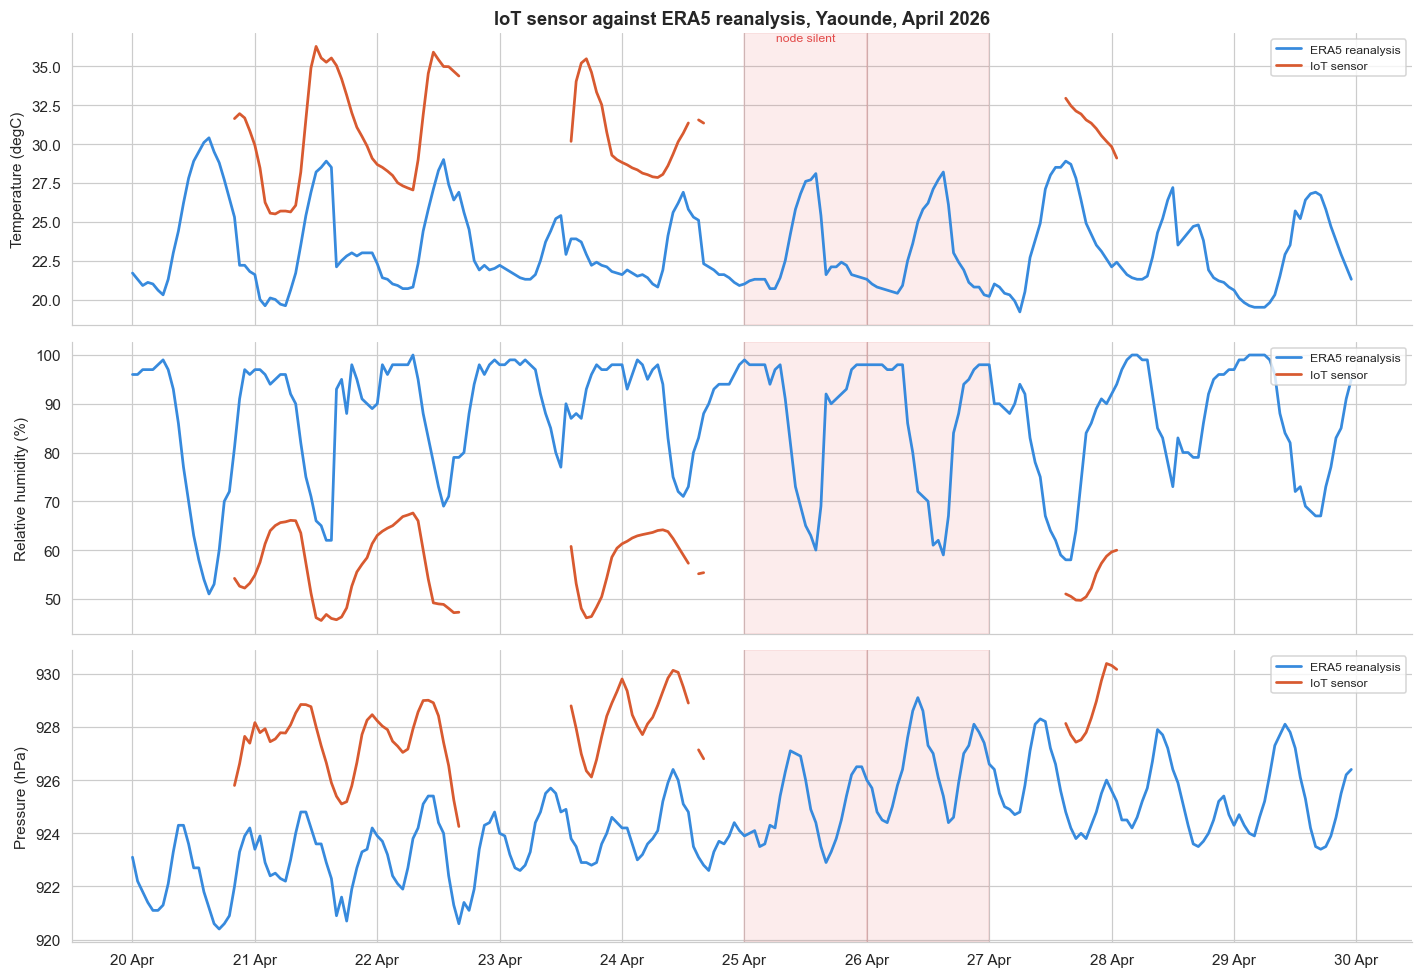

In [8]:
# == FIGURE 1 . the two series side by side ==================================
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

# Reindex onto a complete hourly axis so hours the node missed become NaN.
# Without this matplotlib joins across the gaps and draws a smooth ramp
# where nothing was recorded -- the figure would assert data that does not
# exist.
full_hours = pd.date_range(sh.time.min(), sh.time.max(), freq='h')
sh_gapped = sh.set_index('time').reindex(full_hours).reset_index(names='time')

for ax, (iot, era, lab, unit) in zip(axes, [
        ('T_iot', 'T_era', 'Temperature', 'degC'),
        ('H_iot', 'H_era', 'Relative humidity', '%'),
        ('P_iot', 'P_era', 'Pressure', 'hPa')]):
    ax.plot(om.time, om[era], '-', color=BLUE, lw=1.8, label='ERA5 reanalysis')
    ax.plot(sh_gapped.time, sh_gapped[iot], '-', color=ORANGE, lw=1.8,
            label='IoT sensor')
    ax.set_ylabel(f'{lab} ({unit})')
    ax.legend(fontsize=8, loc='upper right')

for d in missing:
    for ax in axes:
        ax.axvspan(pd.Timestamp(d), pd.Timestamp(d) + pd.Timedelta(days=1),
                   color=RED, alpha=0.10)
if missing:
    axes[0].text(pd.Timestamp(missing[0]) + pd.Timedelta(hours=12),
                 axes[0].get_ylim()[1], 'node silent',
                 ha='center', va='top', fontsize=8, color=RED)

axes[0].set_title('IoT sensor against ERA5 reanalysis, Yaounde, April 2026',
                  fontweight='bold')
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig01_series.png', bbox_inches='tight')
plt.show()

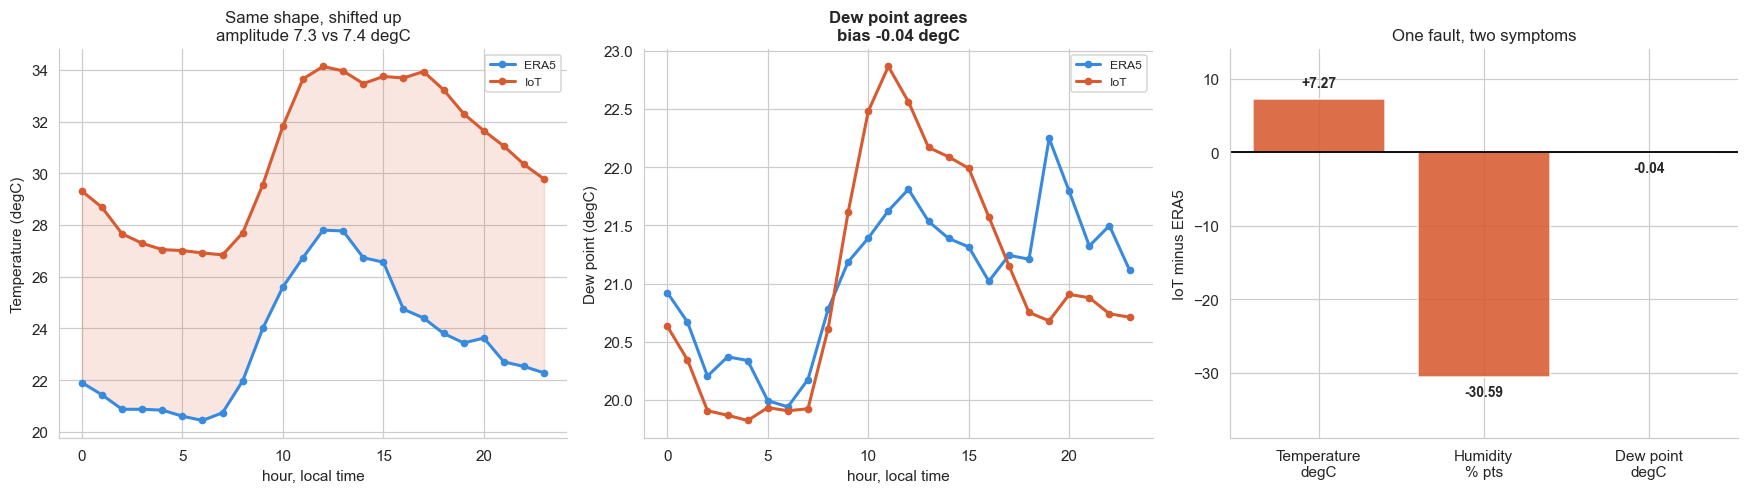

In [9]:
# == FIGURE 2 . the diagnosis ================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

a = axes[0]
a.plot(dc.index, dc.T_era, '-o', color=BLUE, ms=4, lw=2, label='ERA5')
a.plot(dc.index, dc.T_iot, '-o', color=ORANGE, ms=4, lw=2, label='IoT')
a.fill_between(dc.index, dc.T_era, dc.T_iot, color=ORANGE, alpha=0.15)
a.set_xlabel('hour, local time')
a.set_ylabel('Temperature (degC)')
a.set_title(f'Same shape, shifted up\namplitude {amp_iot:.1f} vs {amp_era:.1f} degC',
            fontsize=11)
a.legend(fontsize=8)

a = axes[1]
a.plot(dc.index, dc.Td_era, '-o', color=BLUE, ms=4, lw=2, label='ERA5')
a.plot(dc.index, dc.Td_iot, '-o', color=ORANGE, ms=4, lw=2, label='IoT')
a.set_xlabel('hour, local time')
a.set_ylabel('Dew point (degC)')
a.set_title(f'Dew point agrees\nbias {(m.Td_iot - m.Td_era).mean():+.2f} degC',
            fontsize=11, fontweight='bold')
a.legend(fontsize=8)

a = axes[2]
vals = [dT, (m.H_iot - m.H_era).mean(), (m.Td_iot - m.Td_era).mean()]
bars = a.bar(['Temperature\ndegC', 'Humidity\n% pts', 'Dew point\ndegC'],
             vals, color=[ORANGE, ORANGE, GREEN], alpha=0.88, edgecolor='white')
a.axhline(0, color='black', lw=1.2)
a.set_ylabel('IoT minus ERA5')
a.set_title('One fault, two symptoms', fontsize=11)
# Labels sit just outside the bar end, with headroom added below so a large
# negative value cannot collide with the tick labels.
lo, hi = min(vals), max(vals)
a.set_ylim(lo - 0.22 * (hi - lo), hi + 0.18 * (hi - lo))
for b, v in zip(bars, vals):
    off = 0.03 * (hi - lo)
    a.text(b.get_x() + b.get_width() / 2, v + (off if v >= 0 else -off),
           f'{v:+.2f}', ha='center', fontweight='bold', fontsize=9,
           va='bottom' if v >= 0 else 'top')

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig02_diagnosis.png', bbox_inches='tight')
plt.show()

## 5 . What the disagreement costs, in predicted cases

Agreement statistics mean nothing to an epidemiologist until they are expressed
in the model's own units. Three scenarios, scored through the deployed NO-LAG
regressor:

| | April 2026 inputs |
|---|---|
| **A** | reanalysis only, the operational baseline |
| **B** | raw sensor for T/H/P, reanalysis for rainfall |
| **C** | sensor with the temperature offset removed, humidity recomputed at its own measured dew point |

The two lag months come from the reanalysis in every scenario: the node has no
history before 20 April. Rainfall always comes from the reanalysis, because the
node cannot measure it at all.

In [10]:
from app.mlops.stages import features as feat

DISTRICT = 'Biyem Assi'
fb = st[st.district == DISTRICT].iloc[0]
POP, THRESHOLD = float(fb.p_totale), float(fb.threshold_75)

hist = pd.read_csv(DATA / 'yaounde_climate_2026_apr_jun.csv', parse_dates=['Date'])
hist['ym'] = hist.Date.dt.to_period('M')
# Columns are named Tm/Hm/Pm/Rm rather than T/H/P/R: `frame.T` is pandas'
# transpose, so a column called T can never be read with attribute access.
mon = (hist.groupby('ym')
       .agg(Tm=('Temperature_C', 'mean'), Hm=('Humidity_%', 'mean'),
            Pm=('Pressure_hPa', 'mean'), Rm=('Precipitation_mm', 'sum')))
mon.index = mon.index.astype(str)          # Period index -> plain label lookup
COLS = ['Tm', 'Hm', 'Pm', 'Rm']
LAGS = [(2026, mth) + tuple(float(x) for x in mon.loc[f'2026-{mth:02d}', COLS])
        for mth in (2, 3)]
APR = mon.loc['2026-04', COLS].astype(float)

T_iot, H_iot, P_iot = m.T_iot.mean(), m.H_iot.mean(), m.P_iot.mean()
T_cor = T_iot - dT
H_cor = 100 * es(m.Td_iot.mean()) / es(T_cor)

SCEN = {
    'A . reanalysis only':         (APR['Tm'], APR['Hm'], APR['Pm'], APR['Rm']),
    'B . raw sensor':              (float(T_iot), float(H_iot),
                                    float(P_iot), APR['Rm']),
    'C . offset-corrected sensor': (float(T_cor), float(H_cor),
                                    APR['Pm'], APR['Rm']),
}


def score(T, H, P, R):
    df = pd.DataFrame(LAGS + [(2026, 4, T, H, P, R)],
                      columns=['year', 'month', 'Temperature_C', 'Humidity_pct',
                               'Pressure_hPa', 'Precipitation_mm'])
    df['district'] = DISTRICT
    # Values arrive as numpy scalars via .loc on a Period index, which makes
    # pandas infer object dtype; xgboost then refuses the frame.
    for col in ('Temperature_C', 'Humidity_pct', 'Pressure_hPa',
                'Precipitation_mm'):
        df[col] = pd.to_numeric(df[col], errors='raise').astype(float)
    df = feat.attach_static(feat.add_temporal_features(df), st)
    X = df[df.month == 4][feat.FEAT_NOLAG]
    cases = float(np.expm1(bundle.regressor_nolag.predict(X))[0])
    proba = float(bundle.classifier_nolag.predict_proba(X)[:, 1][0])
    return cases, cases / POP * 1000, proba


print(f'{DISTRICT}: population {POP:,.0f}, High threshold {THRESHOLD:.2f} /1000')
print(f'Correction in C: {T_iot:.2f} - {dT:.2f} = {T_cor:.2f} degC, humidity')
print(f'recomputed at dew point {m.Td_iot.mean():.2f} degC gives {H_cor:.1f} %\n')

res = []
for name, (T, H, P, R) in SCEN.items():
    c, i, p = score(T, H, P, R)
    res.append({'scenario': name, 'T': T, 'H': H, 'P': P, 'rain': R,
                'cases': round(c), 'incidence': i,
                'risk': 'High' if i > THRESHOLD else 'Low', 'P_high': p})
res = pd.DataFrame(res)
display(res.style.format({'T': '{:.2f}', 'H': '{:.1f}', 'P': '{:.1f}',
                          'rain': '{:.1f}', 'incidence': '{:.2f}', 'P_high': '{:.3f}'}))

base = res.iloc[0]
print()
for _, r in res.iloc[1:].iterrows():
    d = r.cases - base.cases
    print(f'  {r.scenario:<32} {d:+7.0f} cases ({d / base.cases * 100:+6.1f} %)'
          f'   incidence {r.incidence - base.incidence:+.2f}')

Biyem Assi: population 410,370, High threshold 14.28 /1000
Correction in C: 30.73 - 7.27 = 23.46 degC, humidity
recomputed at dew point 21.02 degC gives 86.2 %



,scenario,T,H,P,rain,cases,incidence,risk,P_high
0,A . reanalysis only,23.56,85.2,933.0,210.3,5482,13.36,Low,0.789
1,B . raw sensor,30.73,56.8,927.9,210.3,3406,8.30,Low,0.782
2,C . offset-corrected sensor,23.46,86.2,933.0,210.3,5413,13.19,Low,0.807



  B . raw sensor                     -2076 cases ( -37.9 %)   incidence -5.06
  C . offset-corrected sensor          -69 cases (  -1.3 %)   incidence -0.17


## 6 . Why a 2 percent-importance variable causes a 38 percent error

Temperature carries very little of the model's explanatory weight. A large error
from a small-weight feature looks contradictory until you ask *where the biased
value lands* relative to the data the model was trained on.

In [11]:
# -- Feature importance ------------------------------------------------------
imp = bundle.regressor_nolag.get_booster().get_score(importance_type='gain')
tot = sum(imp.values())
grp = {'geography': 0., 'season': 0., 'pressure': 0., 'humidity': 0.,
       'precipitation': 0., 'temperature': 0.}
for k, v in imp.items():
    pct, kl = v / tot * 100, k.lower()
    if kl.startswith('shp') or kl == 'cluster':  grp['geography'] += pct
    elif 'temperature' in kl:                    grp['temperature'] += pct
    elif 'humidity' in kl:                       grp['humidity'] += pct
    elif 'pressure' in kl:                       grp['pressure'] += pct
    elif 'precipitation' in kl:                  grp['precipitation'] += pct
    else:                                        grp['season'] += pct

print('NO-LAG regressor, importance by gain:')
for k, v in sorted(grp.items(), key=lambda kv: -kv[1]):
    print(f'  {k:<15}{v:>7.2f} %  ' + '=' * int(v / 2))
sensed = grp['temperature'] + grp['humidity'] + grp['pressure']
print(f'\n  measured by the sensor : {sensed:.1f} %')
print(f'  missing, rainfall      : {grp["precipitation"]:.1f} %')

# -- Where the biased value sits relative to training ------------------------
clim = pd.read_csv(DATA / 'cameroon_districts_climate.csv',
                   usecols=['Location', 'Date', 'Temperature_C'])
clim['Date'] = pd.to_datetime(clim.Date)
tm = (clim.groupby(['Location', clim.Date.dt.to_period('M')])['Temperature_C']
      .mean().reset_index())
mask = tm.Location.str.contains('Yaounde|Biyem|Efoulan|Nkolndongo',
                                case=False, na=False)
loc = tm[mask]['Temperature_C']

print(f'\nTraining monthly temperature, nationwide : '
      f'{tm.Temperature_C.min():.2f} .. {tm.Temperature_C.max():.2f} degC')
print(f'Training monthly temperature, Yaounde   : '
      f'{loc.min():.2f} .. {loc.max():.2f} degC  n={len(loc)}, mean {loc.mean():.2f}')
print(f'\n  raw sensor reads {T_iot:.2f} degC')
print(f'  that is {(T_iot - loc.mean()) / loc.std():.1f} standard deviations above the local mean')
print(f'  Yaounde training months that ever reached it: {(loc > T_iot).sum()} / {len(loc)}')
print(f'  nationwide months that reach it            : {(tm.Temperature_C > T_iot).sum()}'
      f' / {len(tm)}, {(tm.Temperature_C > T_iot).mean() * 100:.1f} %')
print('\n>> The biased reading is not extreme nationally, it is ordinary for the')
print('   Sahelian north. It is impossible for Yaounde. The trees route the')
print('   sample down branches learnt from a different climate zone, so the error')
print('   has nothing to do with how much weight temperature carries.')

NO-LAG regressor, importance by gain:
  geography        84.88 %  ==========================================
  season            4.30 %  ==
  pressure          3.37 %  =
  humidity          3.06 %  =
  precipitation     2.39 %  =
  temperature       2.00 %  =

  measured by the sensor : 8.4 %
  missing, rainfall      : 2.4 %



Training monthly temperature, nationwide : 14.66 .. 35.15 degC
Training monthly temperature, Yaounde   : 21.66 .. 25.39 degC  n=114, mean 23.35

  raw sensor reads 30.73 degC
  that is 7.8 standard deviations above the local mean
  Yaounde training months that ever reached it: 0 / 114
  nationwide months that reach it            : 215 / 4484, 4.8 %

>> The biased reading is not extreme nationally, it is ordinary for the
   Sahelian north. It is impossible for Yaounde. The trees route the
   sample down branches learnt from a different climate zone, so the error
   has nothing to do with how much weight temperature carries.


In [12]:
# -- Would the pipeline validator have caught it? ----------------------------
from app.mlops.stages.validation import validate_climate, BOUNDS

daily = (sensor.set_index('t').resample('D')
         .agg(Temperature_C=('temperature', 'mean'),
              Humidity_pct=('relative_humidity', 'mean'),
              Pressure_hPa=('barometric_pressure', 'mean'))
         .dropna().reset_index().rename(columns={'t': 'Date'}))
daily['Location'] = DISTRICT
daily['Precipitation_mm'] = 0.0

rep = validate_climate(daily, expected_districts={DISTRICT})
print('Bounds in force:', {k: v[:2] for k, v in BOUNDS.items()})
verdict = 'PASSED' if rep.passed else 'FAILED'
print(f'\nVerdict on the raw sensor stream: {verdict}   {rep.summary()}')
for c in rep.checks:
    if not c.passed:
        print(f'   [{c.severity.value}] {c.name}: {c.detail}')

if rep.passed:
    print('\n>> GAP FOUND. The bounds are nationwide, so a value that is normal for')
    print('   Maroua passes even when it is impossible for Yaounde. A global range')
    print('   cannot catch a locally impossible reading; the validator needs a')
    print('   per-district reference. Actionable finding for')
    print('   6_APP/app/mlops/stages/validation.py.')

Bounds in force: {'Temperature_C': (5.0, 50.0), 'Humidity_pct': (0.0, 100.0), 'Pressure_hPa': (700.0, 1100.0), 'Precipitation_mm': (0.0, 500.0)}

Verdict on the raw sensor stream: PASSED   [OK] 15/16 checks passed · 7 rows · 1 districts
   [warning] continuous_series: 1 district(s) with missing days; worst: ('Biyem Assi', 2)

>> GAP FOUND. The bounds are nationwide, so a value that is normal for
   Maroua passes even when it is impossible for Yaounde. A global range
   cannot catch a locally impossible reading; the validator needs a
   per-district reference. Actionable finding for
   6_APP/app/mlops/stages/validation.py.


In [13]:
# -- Rainfall sensitivity: what does the missing channel actually cost? ------
grid = []
for R in [0, 25, 50, 100, 150, APR['Rm'], 250, 300, 400]:
    c, i, _ = score(T_cor, H_cor, APR['Pm'], R)
    grid.append({'rain_mm': R, 'cases': round(c), 'incidence': i})
grid = pd.DataFrame(grid)
ref = grid[np.isclose(grid.rain_mm, APR['Rm'])].iloc[0]
grid['vs_observed_pct'] = (grid.cases - ref.cases) / ref.cases * 100
display(grid.style.format({'rain_mm': '{:.1f}', 'incidence': '{:.2f}',
                           'vs_observed_pct': '{:+.1f}'}))

span = grid.cases.max() - grid.cases.min()
raw_err = abs(res.iloc[1].cases - base.cases)
print(f'\n  rainfall from 0 to 400 mm moves the forecast by {span:.0f} cases, '
      f'{span / ref.cases * 100:.1f} % of the observed-rain forecast')
print(f'  the uncorrected temperature offset moved it by {raw_err:.0f} cases, '
      f'{raw_err / base.cases * 100:.1f} %')
ratio = raw_err / max(span, 1)
print(f'\n>> The channel the sensor LACKS matters about {ratio:.0f} times less')
print('   than the channel it MIS-MEASURES. Fixing the siting is far more urgent')
print('   than adding a rain gauge.')

,rain_mm,cases,incidence,vs_observed_pct
0,0.0,5273,12.85,-2.6
1,25.0,5262,12.82,-2.8
2,50.0,5401,13.16,-0.2
3,100.0,5415,13.20,+0.0
4,150.0,5427,13.23,+0.3
5,210.3,5413,13.19,+0.0
6,250.0,5256,12.81,-2.9
7,300.0,5283,12.87,-2.4
8,400.0,5293,12.90,-2.2



  rainfall from 0 to 400 mm moves the forecast by 171 cases, 3.2 % of the observed-rain forecast
  the uncorrected temperature offset moved it by 2076 cases, 37.9 %

>> The channel the sensor LACKS matters about 12 times less
   than the channel it MIS-MEASURES. Fixing the siting is far more urgent
   than adding a rain gauge.


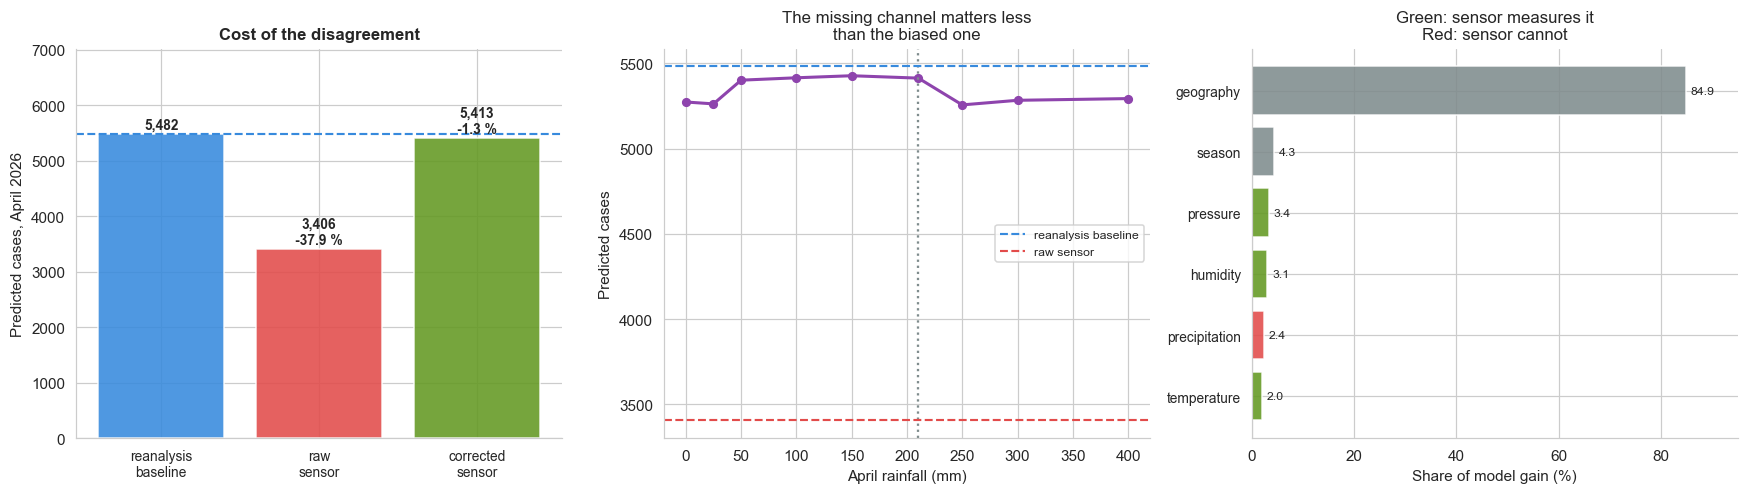

In [14]:
# == FIGURE 3 . what it costs ================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

a = axes[0]
bars = a.bar(range(3), res.cases, color=[BLUE, RED, GREEN],
             alpha=0.88, edgecolor='white')
a.axhline(base.cases, color=BLUE, ls='--', lw=1.4)
a.set_xticks(range(3))
a.set_xticklabels(['reanalysis\nbaseline', 'raw\nsensor', 'corrected\nsensor'],
                  fontsize=9)
a.set_ylabel('Predicted cases, April 2026')
a.set_title('Cost of the disagreement', fontsize=11, fontweight='bold')
for b, v in zip(bars, res.cases):
    d = (v - base.cases) / base.cases * 100
    lbl = f'{v:,.0f}'
    if abs(d) >= 0.05:
        lbl = lbl + f'\n{d:+.1f} %'
    a.text(b.get_x() + b.get_width() / 2, v + 90, lbl,
           ha='center', fontweight='bold', fontsize=9)
a.set_ylim(0, max(res.cases) * 1.28)

a = axes[1]
a.plot(grid.rain_mm, grid.cases, '-o', color=PURPLE, lw=2, ms=5)
a.axvline(APR['Rm'], color=GREY, ls=':', lw=1.5)
a.axhline(base.cases, color=BLUE, ls='--', lw=1.4, label='reanalysis baseline')
a.axhline(res.iloc[1].cases, color=RED, ls='--', lw=1.4, label='raw sensor')
a.set_xlabel('April rainfall (mm)')
a.set_ylabel('Predicted cases')
a.set_title('The missing channel matters less\nthan the biased one', fontsize=11)
a.legend(fontsize=8)

a = axes[2]
g = pd.Series(grp).sort_values()
cols = []
for k in g.index:
    if k in ('temperature', 'humidity', 'pressure'):
        cols.append(GREEN)
    elif k == 'precipitation':
        cols.append(RED)
    else:
        cols.append(GREY)
a.barh(range(len(g)), g.values, color=cols, alpha=0.88, edgecolor='white')
a.set_yticks(range(len(g)))
a.set_yticklabels(g.index, fontsize=9)
a.set_xlabel('Share of model gain (%)')
a.set_xlim(0, g.max() * 1.12)   # keep the 84.9 label inside the axes
a.set_title('Green: sensor measures it\nRed: sensor cannot', fontsize=11)
for i, v in enumerate(g.values):
    a.text(v + 1, i, f'{v:.1f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig03_impact.png', bbox_inches='tight')
plt.show()

---
## 7 . Conclusions

In [15]:
summary = {
    'window_local': f'{sensor.t.min():%Y-%m-%d %H:%M} to {sensor.t.max():%Y-%m-%d %H:%M}',
    'days_spanned': int(len(expected)),
    'complete_days': int(len(complete)),
    'missing_days': [str(d) for d in missing],
    'readings': int(len(sensor)),
    'sampling_interval_s': float(dt.median()),
    'matched_hours': int(len(m)),
    'bias_temperature_C': float(dT),
    'bias_humidity_points': float((m.H_iot - m.H_era).mean()),
    'bias_pressure_hPa': float((m.P_iot - m.P_era).mean()),
    'bias_dewpoint_C': float((m.Td_iot - m.Td_era).mean()),
    'rh_expected_from_offset': float(rh_expected),
    'rh_measured': float(rh_actual),
    'diurnal_amplitude_iot_C': float(amp_iot),
    'diurnal_amplitude_era_C': float(amp_era),
    'cases_baseline': int(base.cases),
    'cases_raw_sensor': int(res.iloc[1].cases),
    'cases_corrected_sensor': int(res.iloc[2].cases),
    'error_raw_pct': float((res.iloc[1].cases - base.cases) / base.cases * 100),
    'error_corrected_pct': float((res.iloc[2].cases - base.cases) / base.cases * 100),
    'rain_sensitivity_pct': float(span / ref.cases * 100),
    'importance_geography_pct': float(grp['geography']),
    'importance_precipitation_pct': float(grp['precipitation']),
    'sensor_T_sd_above_local_mean': float((T_iot - loc.mean()) / loc.std()),
    'validator_passed_raw_stream': bool(rep.passed),
}
(HERE / 'sensor_validation_results.json').write_text(
    json.dumps(summary, indent=2), encoding='utf-8')

print('SUMMARY')
print('=' * 72)
print(f"  temperature bias      {summary['bias_temperature_C']:+7.2f} degC")
print(f"  humidity bias         {summary['bias_humidity_points']:+7.2f} points")
print(f"  DEW POINT bias        {summary['bias_dewpoint_C']:+7.2f} degC   <- instruments agree")
print(f"  forecast, raw         {summary['error_raw_pct']:+7.1f} %")
print(f"  forecast, corrected   {summary['error_corrected_pct']:+7.1f} %")
print(f"  rainfall sensitivity  {summary['rain_sensitivity_pct']:7.1f} % over 0-400 mm")
print('=' * 72)
n_png = len(list(OUT_DIR.glob('*.png')))
print(f'\nResults written to sensor_validation_results.json, {n_png} figures')

SUMMARY
  temperature bias        +7.27 degC
  humidity bias          -30.59 points
  DEW POINT bias          -0.04 degC   <- instruments agree
  forecast, raw           -37.9 %
  forecast, corrected      -1.3 %
  rainfall sensitivity      3.2 % over 0-400 mm

Results written to sensor_validation_results.json, 3 figures


### What this establishes

**The sensor hardware is sound.** The two instruments agree on the moisture
content of the air to within a few hundredths of a degree of dew point, and they
trace the same diurnal shape to within a tenth of a degree of amplitude. Nothing
here suggests a faulty element.

**It has exactly one fault: a constant temperature offset of about 7 degrees.**
The offset is the same by night as by day, which rules out solar loading on the
housing and points instead to self-heating or a poorly ventilated enclosure. The
entire 30-point humidity deficit is a mechanical consequence of that single
offset, and no separate humidity fault exists.

**Uncorrected, that one fault costs roughly 38 percent of the forecast.**
Corrected, the sensor and the reanalysis produce forecasts within about
1 percent of each other. The correction is a subtraction and a psychrometric
identity; it needs no retraining and no new data.

**The error has nothing to do with how much weight the model puts on
temperature.** Temperature carries around 2 percent of the model's gain, while
geography carries about 85. What matters is not the feature's weight but *where
the biased value lands*: 30.7 degrees is unremarkable for the Sahelian north and
has never once occurred in Yaounde's training history. The model is being asked
about a place that does not exist, and answers accordingly. **Feature importance
is not a guide to how much a sensor fault will cost.**

**The missing rain gauge is the lesser problem.** Rainfall across its whole
plausible range moves this forecast by a few percent, an order of magnitude less
than the temperature offset. Rainfall must still come from the reanalysis, since
the model does use it, but a hybrid feed is an adequate answer whereas a
mis-sited thermometer is not.

**The pipeline validator does not catch this, and should.** Its bounds are
nationwide, so a reading that is normal for Maroua passes even when it is
impossible for Yaounde. That is a genuine gap in
`6_APP/app/mlops/stages/validation.py`.

### Recommendations

1. **Re-site or shield the node before trusting any reading.** A ventilated
   radiation shield, and separation from anything that dissipates heat, the
   board itself included. Then re-run this notebook: the dew-point agreement
   already proves the element is good, so the offset should simply vanish.
2. **Until then, apply the measured offset in software**, and recompute relative
   humidity from the corrected temperature and the sensor's own dew point rather
   than trusting the reported percentage.
3. **Add a per-district plausibility check** to the validator: compare each
   reading against that district's own training distribution, not against the
   national range. A z-score beyond about 4 relative to the district's history
   should block the run.
4. **Keep rainfall on the reanalysis feed.** A tipping-bucket gauge is worth
   adding eventually, but it is not what stands between this system and a usable
   forecast.
5. **Do not conclude anything about accuracy from this capture.** Seven days, one
   of them complete, cannot validate a monthly model. What it can and does
   establish is instrument agreement, which is a prerequisite for everything
   else.

### Limitations

1. **Seven days, one complete, two missing entirely.** Enough for an
   instrument-agreement study, not for anything about forecast skill.
2. **A single node, and its location is assumed.** The log carries no
   coordinates; Yaounde is taken from the deployment described in the thesis and
   is consistent with the observed pressure. If the node is elsewhere, the
   comparison target changes and the offset must be re-measured.
3. **The pressure comparison is convention-dependent.** The project's own
   Yaounde file and a fresh Open-Meteo call differ by about 8 hPa for the same
   month, so the sensor's pressure offset should not be read too precisely.
4. **The offset is measured over one week in one season.** It should be
   re-estimated once a longer record exists, and it may not be constant across
   the year.